In [149]:
import pandas as pd
import numpy as np
import os
import datetime as dt
import missingno as msno
import seaborn as sns
import matplotlib as plt
import matplotlib.pyplot as plt
import json


### Data frame creator

In [231]:
df_smog = pd.read_csv('../data/smog_raw.csv', encoding='utf-8-sig')
df_smog2 = pd.read_csv('../data/smog_raw2.csv', encoding='utf-8-sig')


### Pokazanie czy działa formatowanie - brak błędów polskich znaków - niestety nie potrafie naprawić

In [207]:
print(df_smog['NAME'].head())


0    SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...
1                    SZKO?A PODSTAWOWA WE WRZ?SOWICACH
2                        ZESP?? SZK?? NR 1 W PSZCZYNIE
3    ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...
4    SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...
Name: NAME, dtype: str


### Nazwy nagłówków

In [ ]:
print(df_smog.columns)


### Opis danych

In [ ]:
df_smog.isna().info()


### Opis typu danych w kolumnach

In [ ]:
print(df_smog.dtypes)


### Zmiana typu danych w kolumnie 'Date' na datetime

In [155]:
df_smog['TIMESTAMP_DATETIME'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')


### Wyciągam datę

In [156]:
df_smog['TYLKO_DATA'] = df_smog['TIMESTAMP_DATETIME'].dt.date


### Wyciągamy sam czas (Format: GG:MM:SS)

In [ ]:
df_smog['TYLKO_CZAS'] = df_smog['TIMESTAMP_DATETIME'].dt.time


### Usuwamy kolumnę pomocniczą

In [158]:
df_smog = df_smog.drop(columns=['TIMESTAMP_DATETIME'])


### Podgląd danych po zmianie formatowania daty i czasu

In [ ]:
print(df_smog['TYLKO_CZAS'].head())


### Podgląd nazw nagłówków w tabeli

In [ ]:
df_smog.head(2)


### Podstawowe statystyki opisowe [według typów danych]

In [ ]:
df_smog.describe()


Statystyki

In [ ]:
display(df_smog.describe())


Pokaż braki

In [ ]:
print(df_smog.isnull().sum())


Pokaż dane temperatury

In [ ]:
df_smog.sort_values(['TEMPERATURE_AVG']).head(20)


Czyszczenie błędów w danych - temperatura powinna byc powyżej >10 stopni celc

In [ ]:
df_smog = df_smog[df_smog['TEMPERATURE_AVG'] >= 10]


Usuwanie wierszy z brakami w lokalizacjach

In [ ]:
df_smog = df_smog[(df_smog['LATITUDE'] != 0) & (df_smog['LONGITUDE'] != 0)]


### Mapa braków

In [ ]:
sns.heatmap(df_smog.isna())


Przyczyny braku

In [ ]:
msno.matrix(df_smog)


Przyczyny braków

In [ ]:
msno.heatmap(df_smog)


### Set variables

Dendogram

<Axes: >

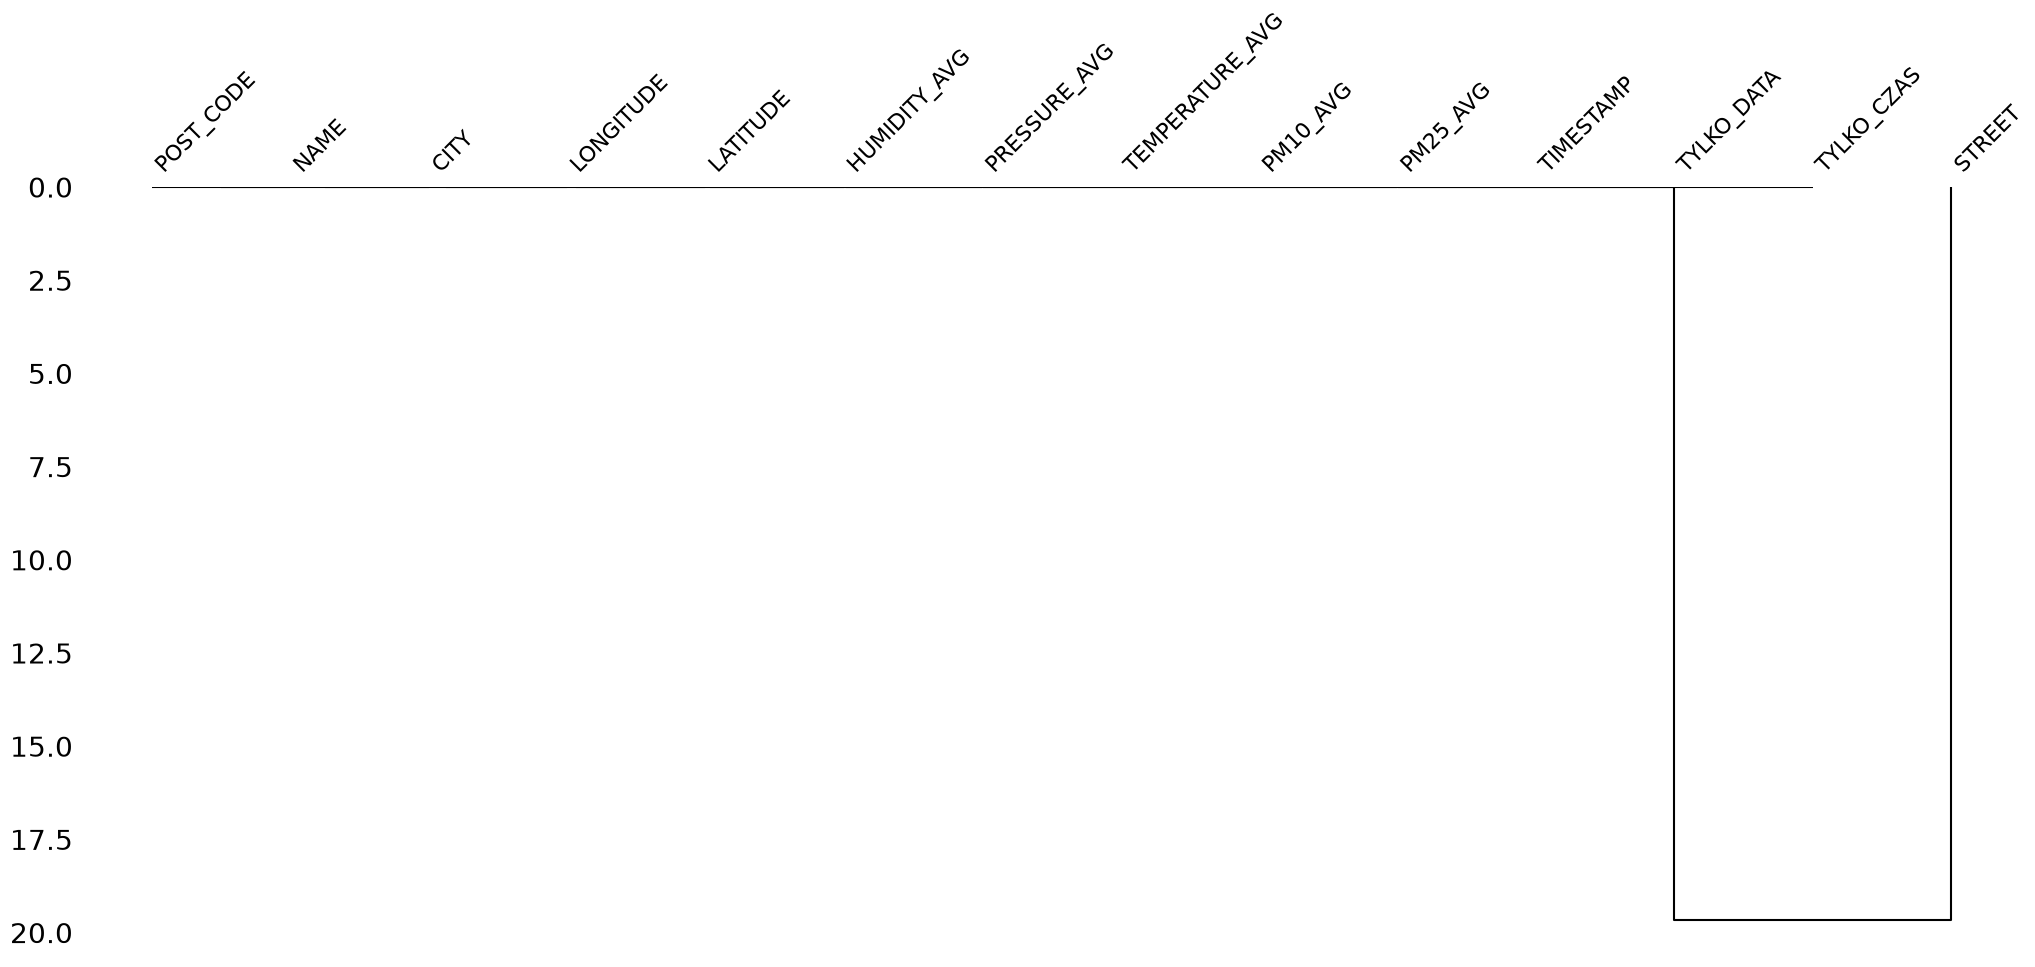

In [ ]:
msno.dendrogram(df_smog)


Usuwanie kolumny "STREET"

In [ ]:
df_smog.drop(columns='STREET')


,NAME,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
0,SZKO?A PODSTAWOWA IM. MARIANA FALSKIEGO W KRAS...,63-522,KRASZEWICE,18.224030,51.515630,99.900000,1011.766667,19.166667,8.333333,4.606667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1,SZKO?A PODSTAWOWA WE WRZ?SOWICACH,32-040,WRZ?SOWICE,19.942820,49.961030,58.408333,978.891667,27.316667,11.525000,10.300000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
2,ZESP?? SZK?? NR 1 W PSZCZYNIE,43-200,PSZCZYNA,18.945706,49.965883,99.900000,999.900000,25.933333,27.733333,16.193333,2026-07-01 00:00:00.0,2026-07-01,00:00:00
3,ZESP?? SZK?? IM. POWSTA?C?W WIELKOPOLSKICH W J...,63-421,JANK?W PRZYGODZKI,17.788907,51.596172,99.900000,992.400000,16.400000,21.300000,11.150000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
4,SZKO?A PODSTAWOWA NR 7 IM. ?O?NIERZY WRZE?NIA ...,43-229,?WIKLICE,18.989839,49.971937,92.666667,986.333333,26.366667,27.633333,14.266667,2026-07-01 00:00:00.0,2026-07-01,00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,SZKO?A PODSTAWOWA IM.BOHATER?W WRZE?NIA 1939R....,34-240,JORDAN?W,19.834938,49.653449,81.545455,960.445455,23.745455,20.445455,20.190909,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1626,PRZEDSZKOLE NR 10 W PIASECZNIE,05-500,PIASECZNO,21.017680,52.072370,51.491667,1006.391667,26.358333,3.325000,3.050000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1627,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,55-020,WILCZK?W,16.989396,50.966512,71.483333,998.225000,25.333333,9.641667,9.375000,2026-07-01 00:00:00.0,2026-07-01,00:00:00
1628,PRZEDSZKOLE SAMORZ?DOWE W GOLI,63-800,GOLA,16.944640,51.870920,82.033333,1002.358333,22.691667,4.925000,4.925000,2026-07-01 00:00:00.0,2026-07-01,00:00:00


In [170]:
area_dict = {
    "00-09": "mazowieckie",
    "10-19": "warminsko-mazurskie",
    "20-29": "lubelskie",
    "30-39": "malopolskie",
    "50-59": "dolnoslaskie",
    "60-69": "wielkopolskie",
    "70-79": "zachodniopomorskie",
    "80-89": "pomorskie",
    "90-99": "lodzkie"
}
smog_columns = ['LONGITUDE', 'LATITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG', 'PM25_AVG']


In [ ]:
print(df_smog[smog_columns].head(10))


   LONGITUDE   LATITUDE  HUMIDITY_AVG  PRESSURE_AVG  TEMPERATURE_AVG  \
0  18.224030  51.515630     99.900000   1011.766667        19.166667   
1  19.942820  49.961030     58.408333    978.891667        27.316667   
2  18.945706  49.965883     99.900000    999.900000        25.933333   
3  17.788907  51.596172     99.900000    992.400000        16.400000   
4  18.989839  49.971937     92.666667    986.333333        26.366667   
5  18.774985  49.960356     73.833333    992.066667        27.033333   
6  18.906757  49.958244     99.900000    991.266667        25.200000   
7  16.896800  52.348100     99.900000   1001.400000        22.366667   
8  17.822685  51.590230     63.800000   1014.200000        19.666667   
9  17.660240  51.580630     63.033333   1001.233333        25.566667   

    PM10_AVG   PM25_AVG  
0   8.333333   4.606667  
1  11.525000  10.300000  
2  27.733333  16.193333  
3  21.300000  11.150000  
4  27.633333  14.266667  
5  29.300000  16.576667  
6  20.133333  12.673333  

### Insert area column and get postal code area number

In [172]:
df_smog.insert(2, 'AREA', df_smog['POST_CODE'].astype(str).str[:2].astype(int))


### Data frame shape

In [ ]:
df_smog.shape


In [ ]:
df_smog2.shape


### Data frame first look

In [ ]:
df_smog


### Format float values with precission to 1

In [176]:
for x in smog_columns:
    df_smog[f"{x}"] = df_smog[f"{x}"].round(1)
    df_smog2[f"{x}"] = df_smog2[f"{x}"].round(1)


### Strip '-' from post code

In [177]:
for x in df_smog['POST_CODE']:
    df_smog['POST_CODE'] = df_smog['POST_CODE'].str.replace("-", "")
    df_smog2['POST_CODE'] = df_smog2['POST_CODE'].str.replace("-", "")


In [ ]:
df_smog.head(5)


In [ ]:
df_smog2.tail(5)


### Shape after first format

In [ ]:
df_smog.shape


In [ ]:
df_smog2.shape


### Data frame look

In [ ]:
df_smog.head(5)


In [183]:
df_smog2.tail(5)


,NAME,STREET,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP
1616,PRZEDSZKOLE NR 10 W PIASECZNIE,NADARZY?SKA,05500,PIASECZNO,21.0,52.1,74.6,1004.4,20.2,2.3,2.1,2026-07-02 11:00:00.0
1617,SZKO?A PODSTAWOWA IM. JANA PAW?A II W WILCZKOWIE,UL. MIKO?AJA KOPERNIKA,55020,WILCZK?W,17.0,51.0,54.0,1000.8,24.9,3.5,3.3,2026-07-02 11:00:00.0
1618,PRZEDSZKOLE SAMORZ?DOWE W GOLI,NaN,63800,GOLA,16.9,51.9,64.6,1003.8,23.0,2.0,2.0,2026-07-02 11:00:00.0
1619,SPO?ECZNA SZKO?A PODSTAWOWA W GZACH,NaN,06126,GZY,20.9,52.7,64.0,1003.0,22.5,2.6,2.1,2026-07-02 11:00:00.0
1620,ZESP?? SZKOLNO-PRZEDSZKOLNY W KSI??U WIELKIM,UL. MIKO?AJA REJA,32210,KSI?? WIELKI,20.1,50.4,84.6,987.2,16.4,19.4,15.0,2026-07-02 11:00:00.0


### -[] Set missing values to 0 in smog_columns 

In [184]:
for x in smog_columns:
    if df_smog[f"{x}"].any() == 0.0:
        print(df_smog[f"{x}"])
        #print(df_smog2[f"{x}"])
        #df_smog[f"{x}"] = df_smog2[f"{x}"]
    #print(df_smog[f"{x}"].isna().sum())


### Data frame look

In [ ]:
df_smog


### Check, if every area is in place (longitude and latitude are in Polish area)

In [ ]:
# Define a function and area latitude and longitude min and max values

def check_areas(df):
    area_values = {
        "Latitude.North < 54.835563": df_smog['LATITUDE'] < 54.8,
        "Latitude.South > 49.002063": df_smog['LATITUDE'] > 49.0,
        "Longitude.East < 24.145562": df_smog['LONGITUDE'] < 24.2,
        "Longitude.West > 14.124562": df_smog['LONGITUDE'] > 14.0
        }
    return area_values

# Define an object table with the area checker

areas = check_areas(df_smog2)

# Print if there are any differences in the areas

for rule, result in areas.items():
    print(f"{rule}: {not result.all()}")


### Check, how many of areas have wrong latitudes\longitudes

In [ ]:
# Check, how many differences are in areas

differences = {rule: ~result for rule, result in areas.items()}
summary = {rule: result.sum() for rule, result in differences.items()}

# Print the number of differences

for rule, count in summary.items():
    print(f"{rule}: {count} differences")


Szukanie korelacji

In [ ]:
sns.barplot(data=df_smog,y='AREA',x='PM10_AVG',errorbar=None,estimator=np.mean,color='steelblue')


In [ ]:
sns.barplot(data=df_smog,y='TEMPERATURE_AVG',x='PM10_AVG',errorbar=None,estimator=np.mean,color='steelblue')


In [ ]:
korelacje = df_smog.corr(numeric_only=True)


In [ ]:
plt.figure(figsize=(10, 8))


In [ ]:
sns.heatmap(korelacje, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)


Usuwanie duplikató

In [ ]:
korelacje_lista = korelacje.unstack().sort_values(key=abs, ascending=False).drop_duplicates()


In [ ]:
korelacje_lista = korelacje_lista[korelacje_lista != 1.0]


In [ ]:
print("Najsilniejsze znalezione korelacje w danych:")


Najsilniejsze znalezione korelacje w danych:


In [ ]:
print(korelacje_lista.head(10))


PM25_AVG      PM10_AVG           0.946034
LONGITUDE     LATITUDE           0.564055
HUMIDITY_AVG  TEMPERATURE_AVG   -0.539954
PRESSURE_AVG  LATITUDE           0.515104
LATITUDE      TEMPERATURE_AVG   -0.466572
PRESSURE_AVG  PM25_AVG          -0.429046
PM25_AVG      LATITUDE          -0.391039
PRESSURE_AVG  TEMPERATURE_AVG   -0.380964
HUMIDITY_AVG  PM10_AVG           0.368392
PM10_AVG      LATITUDE          -0.338963
dtype: float64


### Save dataframe to csv file **Always put as a last cell !**

In [199]:
ts = dt.datetime.now().strftime("%Y%m%d_%H-%M")
#df_smog.to_csv(f"../tests/smog_raw{ts}.csv", index=False)
#df_smog2.to_csv(f"../tests/smog2_raw{ts}.csv", index=False)
